### Reading and understanding data

In [37]:
# Suppressing Warnings
import warnings
warnings.filterwarnings('ignore')

In [38]:
# importing required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [39]:
# read leads dataset
leads = pd.read_csv("Leads.csv")

In [40]:
# view dataset
leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [41]:
# checking non-null count and datatypes of dadtaset
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [42]:
# checking shape of dataset
leads.shape

(9240, 37)

In [43]:
# view describing of data
leads.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [44]:
# checking null values of each column
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

According to above, there are missing values in the dataset.

In [76]:
# checking duplicates
leads[leads.duplicated()]

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity


It is worth noting that the lead dataset does not contain duplicate records. This indicates that there are no identical entries in the dataset.

### Data Cleaning

##### Handling 'Select' Level

There are "select" values in some columns. This may indicate that the customer is not making a particular choice from the available options. In such cases, these "Select" values can essentially be treated as equivalent to NULL, so converting them to NULL values.

In [49]:
# converting 'Select' values to null
leads = leads.replace('Select', np.nan)

In [50]:
# checking null values of each column
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   3380
How did you hear about X Education               7250
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [51]:
# checking null values percentages of each column
percentage_missing = round(leads.isnull().sum()/len(leads.index),2)*100
percentage_missing

Prospect ID                                       0.0
Lead Number                                       0.0
Lead Origin                                       0.0
Lead Source                                       0.0
Do Not Email                                      0.0
Do Not Call                                       0.0
Converted                                         0.0
TotalVisits                                       1.0
Total Time Spent on Website                       0.0
Page Views Per Visit                              1.0
Last Activity                                     1.0
Country                                          27.0
Specialization                                   37.0
How did you hear about X Education               78.0
What is your current occupation                  29.0
What matters most to you in choosing a course    29.0
Search                                            0.0
Magazine                                          0.0
Newspaper Article           

In [52]:
# find missing values greater than 40%
columns_to_drop = percentage_missing[percentage_missing > 40].index
columns_to_drop

Index(['How did you hear about X Education', 'Lead Quality', 'Lead Profile',
       'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
       'Asymmetrique Activity Score', 'Asymmetrique Profile Score'],
      dtype='object')

In [53]:
# drop the columns which have missing values greater than 40%
leads.drop(columns=columns_to_drop, inplace=True)

In [54]:
# checking null values percentages of each column after dropping
round(leads.isnull().sum()/len(leads.index),2)*100

Prospect ID                                       0.0
Lead Number                                       0.0
Lead Origin                                       0.0
Lead Source                                       0.0
Do Not Email                                      0.0
Do Not Call                                       0.0
Converted                                         0.0
TotalVisits                                       1.0
Total Time Spent on Website                       0.0
Page Views Per Visit                              1.0
Last Activity                                     1.0
Country                                          27.0
Specialization                                   37.0
What is your current occupation                  29.0
What matters most to you in choosing a course    29.0
Search                                            0.0
Magazine                                          0.0
Newspaper Article                                 0.0
X Education Forums          

1. Specialization(37% missing values)

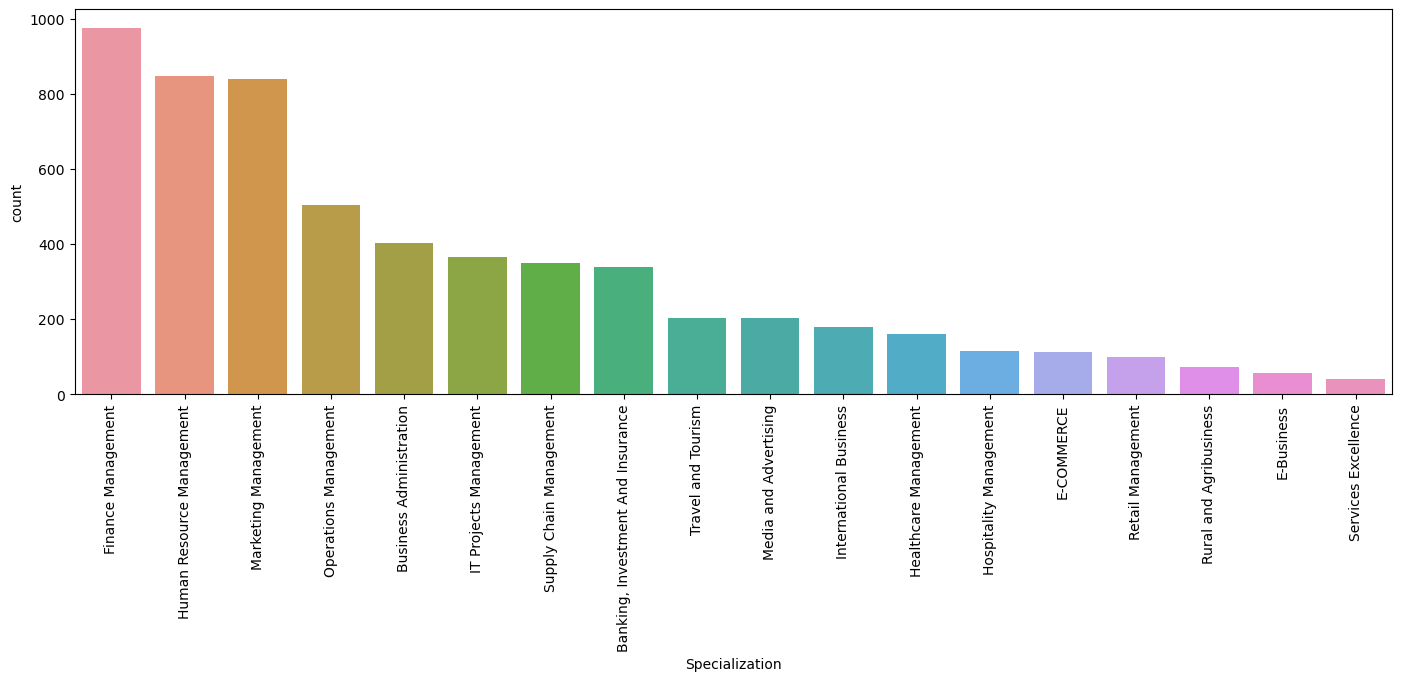

In [55]:
plt.figure(figsize=(17, 5))
sns.countplot(data=leads, x='Specialization', order=leads['Specialization'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

The Specialization column has a significant proportion (37%) of missing values. A lead may leave this column blank for a variety of reasons, such as being a student, not having a specific specialty, or having a specialty not included in the options provided. To address this, create a new category called Other to encompass these cases and provide a more comprehensive representation of the data.

In [56]:
leads['Specialization'] = leads['Specialization'].replace(np.nan, 'Others')

2. Tags(36% missing values)

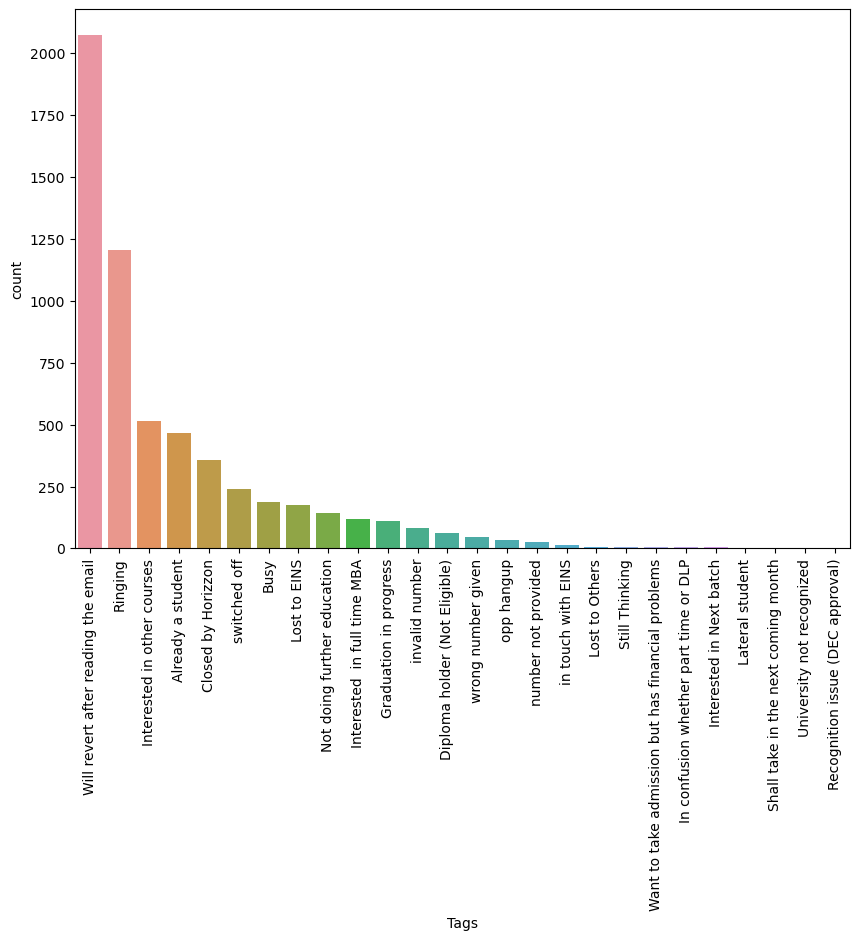

In [57]:
plt.figure(figsize=(10,7))
sns.countplot(data=leads, x='Tags', order=leads['Tags'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

Given that the majority of values in this column are "Will revert after reading the email" to maintain consistency and provide meaningful estimates for missing data, this column is reasonable to impute missing values with this specific value.

In [58]:
# imputing the missing data with 'Will revert after reading the email'
leads['Tags']=leads['Tags'].replace(np.nan,'Will revert after reading the email')

3. What matters most to you in choosing a course(29% missing values)

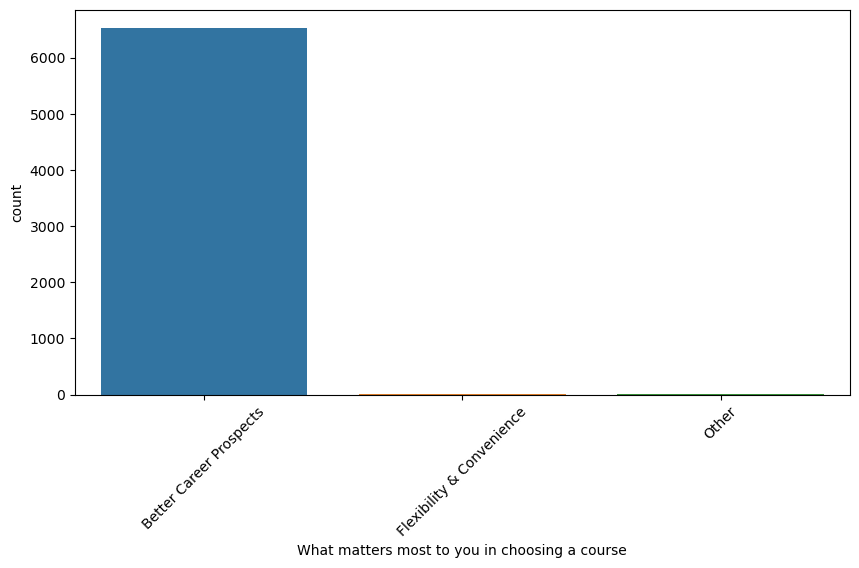

In [59]:
plt.figure(figsize=(10, 5))
sns.countplot(data=leads, x='What matters most to you in choosing a course')
plt.xticks(rotation=45)
plt.show()

In [60]:
# finding the percentage of the each categories
round(leads['What matters most to you in choosing a course'].value_counts(normalize=True),2)*100

Better Career Prospects      100.0
Flexibility & Convenience      0.0
Other                          0.0
Name: What matters most to you in choosing a course, dtype: float64

Because this column exhibits a high degree of skewness in the data distribution, it may be resonable to consider removing this column from the dataset.

In [61]:
# dropping columns
leads=leads.drop('What matters most to you in choosing a course',axis=1)

4. What is your current occupation(29% missing values)

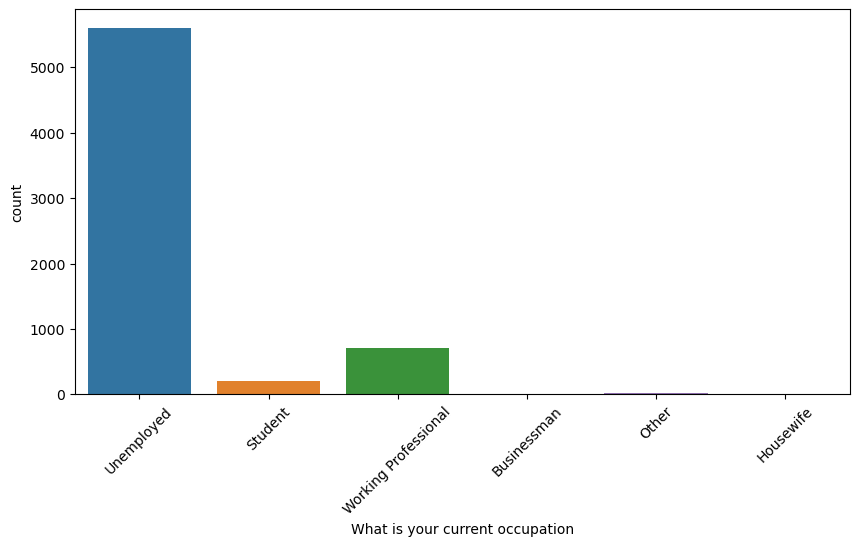

In [62]:
plt.figure(figsize=(10, 5))
sns.countplot(data=leads, x='What is your current occupation')
plt.xticks(rotation=45)
plt.show()

In [63]:
# finding the percentage of each categories
round(leads['What is your current occupation'].value_counts(normalize=True),2)*100

Unemployed              85.0
Working Professional    11.0
Student                  3.0
Other                    0.0
Housewife                0.0
Businessman              0.0
Name: What is your current occupation, dtype: float64

Given that the majority of the values in this column are "unemployed", so to maintain consistency and provide meaningful estimates for missing data, it's reasonable to impute the missing values in this column with this particular value.

In [64]:
# imputing the missing data with 'Unemployed'
leads['What is your current occupation']=leads['What is your current occupation'].replace(np.nan,'Unemployed')

5. Country(27% missing values)

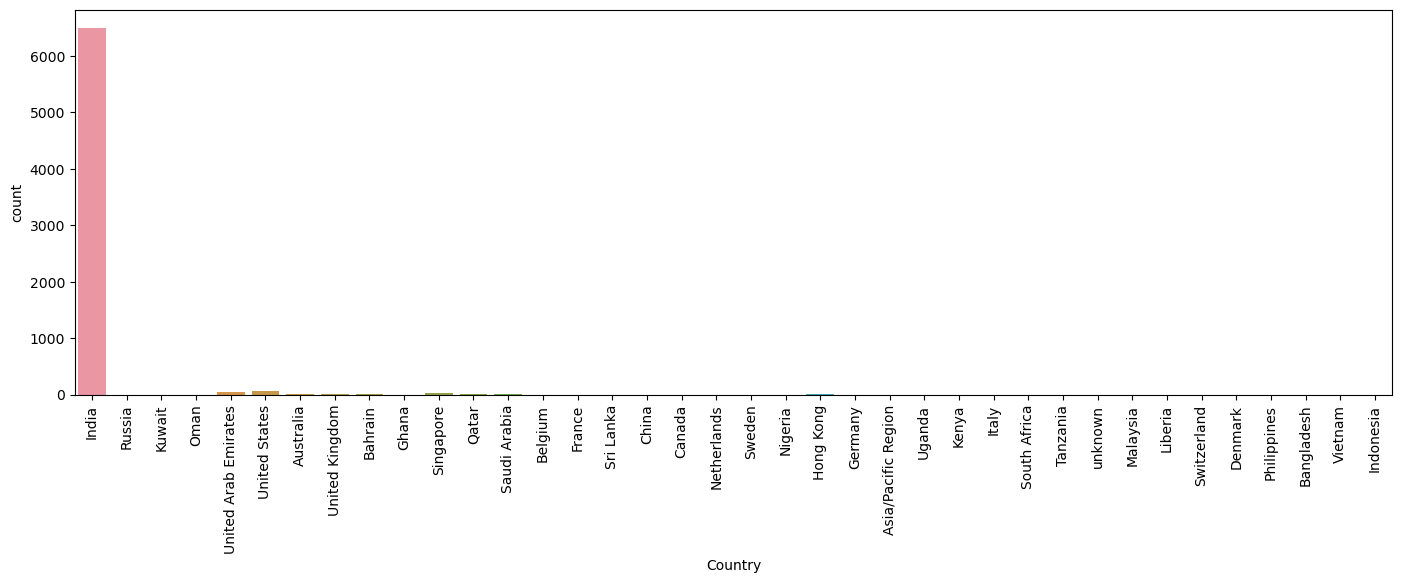

In [65]:
plt.figure(figsize=(17, 5))
sns.countplot(data=leads, x='Country')
plt.xticks(rotation=90)
plt.show()

Although this column exhibits a high degree of skewness in it's distribution, it can be seen that it contains important information about the location of the leads. Given that the majority of values are 'India', to maintain the importance of this information and provide meaningful estimates for missing data, impute missing values in this column with 'India'. It may be reasonable to do so.

In [66]:
# imputing the missing data with 'India'
leads['Country']=leads['Country'].replace(np.nan,'India')

6. City(40% missing values)

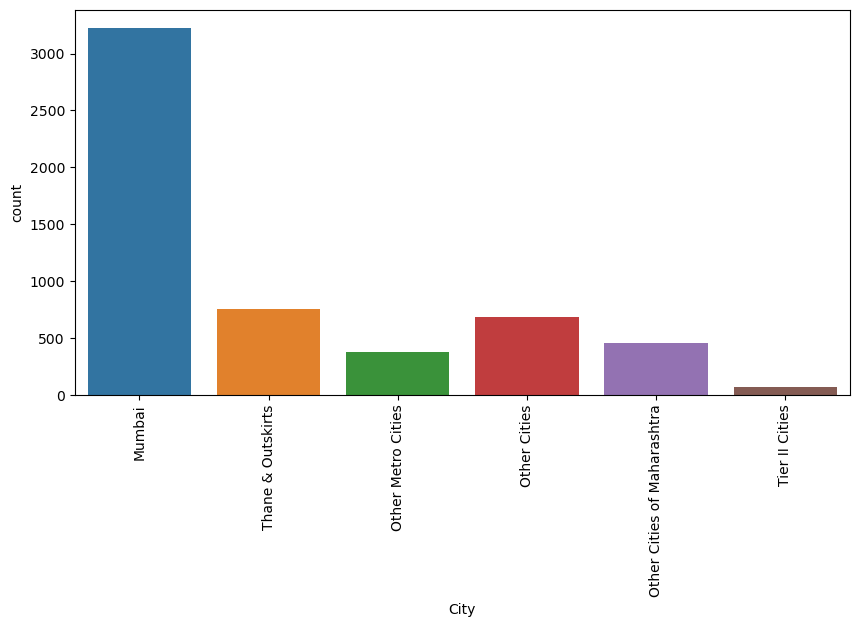

In [68]:
plt.figure(figsize=(10, 5))
sns.countplot(data=leads, x='City')
plt.xticks(rotation=90)
plt.show()

In [69]:
# finding the percentage of each categories
round(leads['City'].value_counts(normalize=True),2)*100

Mumbai                         58.0
Thane & Outskirts              13.0
Other Cities                   12.0
Other Cities of Maharashtra     8.0
Other Metro Cities              7.0
Tier II Cities                  1.0
Name: City, dtype: float64

Given that the majority of the values in this column are "Mumbai", so to maintain consistency and provide meaningful estimates for missing data, it's reasonable to impute the missing values in this column with this particular value.

In [70]:
# imputing the missing data with 'Mumbai'
leads['City']=leads['City'].replace(np.nan,'Mumbai')

In [71]:
# viewing the null percentages after approaching of null values
round(leads.isnull().sum()/len(leads.index),2)*100

Prospect ID                                 0.0
Lead Number                                 0.0
Lead Origin                                 0.0
Lead Source                                 0.0
Do Not Email                                0.0
Do Not Call                                 0.0
Converted                                   0.0
TotalVisits                                 1.0
Total Time Spent on Website                 0.0
Page Views Per Visit                        1.0
Last Activity                               1.0
Country                                     0.0
Specialization                              0.0
What is your current occupation             0.0
Search                                      0.0
Magazine                                    0.0
Newspaper Article                           0.0
X Education Forums                          0.0
Newspaper                                   0.0
Digital Advertisement                       0.0
Through Recommendations                 

The remaining missing values collectively account for less than 2% of the data, so to maintain data quality and integrity, it may be appropriate to remove these rows from the dataset.

In [73]:
# dropping rows with null values
leads.dropna(inplace = True)

In [74]:
# viewing the null percentages after approaching of null values again
round(leads.isnull().sum()/len(leads.index),2)*100

Prospect ID                                 0.0
Lead Number                                 0.0
Lead Origin                                 0.0
Lead Source                                 0.0
Do Not Email                                0.0
Do Not Call                                 0.0
Converted                                   0.0
TotalVisits                                 0.0
Total Time Spent on Website                 0.0
Page Views Per Visit                        0.0
Last Activity                               0.0
Country                                     0.0
Specialization                              0.0
What is your current occupation             0.0
Search                                      0.0
Magazine                                    0.0
Newspaper Article                           0.0
X Education Forums                          0.0
Newspaper                                   0.0
Digital Advertisement                       0.0
Through Recommendations                 

Now that completed the necessary data preprocessing steps, successfully addressed all missing values in dataset and verified that there are no longer any missing data.

In [75]:
# rows retained percentage
(len(leads.index)/9240)*100

98.2034632034632

After data cleaning process, 98% of the original rows were retained, demonstrating the effectiveness of the data cleaning and imputation strategy in preserving a large portion of the dataset.

### Data Visualising

##### Univariate Analysis and Bivariate Analysis

1. Converted: This variable acts as a target variable and indicates whether the lead was successfully converted (indicated by a "1") or not converted (indicated by a "0").

In [77]:
Converted = (sum(leads['Converted'])/len(leads['Converted'].index))*100
Converted

37.85541106458012

The lead conversion rate is 38%, which reflects the percentage of total leads in the dataset that were successfully converted.